### Install dependencies (pip cell)

In [1]:
!uv pip install torch torchvision tifffile opencv-python matplotlib tqdm ipywidgets albumentations

Using Python 3.11.9 environment at: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv
Resolved 76 packages in 982ms                                        
⠙ Preparing packages... (0/10)                                                  
⠙ Preparing packages... (0/10)------------------     0 B/15.01 KiB           
⠙ Preparing packages... (0/10)--------- 15.01 KiB/15.01 KiB         
⠙ Preparing packages... (0/10)--------- 15.01 KiB/15.01 KiB         
annotated-types      ------------------------------     0 B/13.32 KiB
⠙ Preparing packages... (0/10)--------- 15.01 KiB/15.01 KiB         
annotated-types      ------------------------------ 13.32 KiB/13.32 KiB
⠙ Preparing packages... (0/10)--------- 15.01 KiB/15.01 KiB         
annotated-types      ------------------------------ 13.32 KiB/13.32 KiB
⠙ Preparing packages... (0/10)--------- 15.01 KiB/15.01 KiB         
⠙ Preparing packages... (0/10)--------- 13.32 KiB/13.32 KiB         
⠙ Preparing packages... (0/10)--------- 13.32 KiB/13.32 KiB 

### Phase 1 — Data Loading, Normalization, and Dataset

In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import tifffile as tiff
import cv2
import numpy as np
import os
import glob
import albumentations as A
from tqdm.notebook import tqdm

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

class ThermalDataset(Dataset):
    """
    Dataset that pairs thermal TIFF images with binary PNG masks.
    Returns numpy arrays so Albumentations can work on them directly.
    """
    def __init__(self, tiff_dir, mask_dir, view_name=None):
        """
        tiff_dir: Path to patient folders with TIFFs
        mask_dir: Path to patient folders with PNG masks
        view_name: Optional string (e.g. "Anterior", "Lateral", "Oblique") to filter views.
        """
        all_masks = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        
        if view_name:
            self.mask_paths = [p for p in all_masks if view_name.lower() in os.path.basename(p).lower()]
            print(f"Filtered dataset for view '{view_name}': {len(self.mask_paths)} masks found.")
        else:
            self.mask_paths = all_masks
            print(f"Dataset initialized with {len(self.mask_paths)} masks.")
            
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]

        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)

        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]

        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)

        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff):
                tiff_path = p_tiff
                break

        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # Load and normalize TIFF
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = ((raw_data - t_min) / (t_max - t_min)).astype(np.float32)
        img_256 = cv2.resize(normalized, (256, 256), interpolation=cv2.INTER_AREA)

        # Load mask
        img_array = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not read mask: {mask_path}")
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # Return as numpy HxW arrays (Albumentations expects this)
        return img_256, mask_256


class AugmentedDataset(Dataset):
    """Wraps ThermalDataset and applies Albumentations transforms."""
    def __init__(self, base_dataset, transform=None):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, mask = self.base[idx]  # HxW numpy float32

        if self.transform is not None:
            # Albumentations expects HxW or HxWxC numpy arrays
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        # Convert to (1, H, W) tensors
        img_t = torch.from_numpy(img).unsqueeze(0)
        mask_t = torch.from_numpy(mask).unsqueeze(0)
        return img_t, mask_t


# ── V2 High-Intensity Augmentation pipeline ──
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.08,    # ±8% translation
        scale_limit=0.15,    # ±15% scaling
        rotate_limit=15,     # ±15° rotation
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.6,
    ),
    A.ElasticTransform(
        alpha=120,           # Increased intensity for more synthetic shapes
        sigma=12,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4,
    ),
    A.GridDistortion(
        num_steps=5, 
        distort_limit=0.3, 
        p=0.3
    ),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.2), # Contrast enhancement
    A.CoarseDropout(
        max_holes=8, 
        max_height=20, 
        max_width=20, 
        min_holes=2, 
        p=0.3
    ), # Robustness to occlusion
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5,
    ),
])

val_transform = None  # No augmentation for validation

# ── Paths (Corrected for DNP-3DDMR-IR workspace) ──
TIFF_BASE = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
MASK_BASE = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/GroundTruth_Masks"

# TIFF_BASE = r"C:\Users\User\Documents\Skripsi Faiz_DL\DNP-3DDMR-IR\data\organized_by_patient"
# MASK_BASE = r"C:\Users\User\Documents\Skripsi Faiz_DL\DNP-3DDMR-IR\data\GroundTruth_Masks"

# ── Split Logic ──
# 78/22 (Paper standard): 126 train / 36 test. Best for maximizing learning.
# 70/30 (Common standard): 113 train / 49 test. More robust validation.
# 60/40 (Strict): 97 train / 65 test. Risk of underfitting on small datasets.

TRAIN_SPLIT = 0.70  # Change to 0.70 or 0.60 if you want more test data
full_dataset = ThermalDataset(TIFF_BASE, MASK_BASE, view_name=None)
n_total = len(full_dataset)
n_train = int(TRAIN_SPLIT * n_total)
n_test  = n_total - n_train

train_set_raw, test_set_raw = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Wrap with augmentation
train_set = AugmentedDataset(train_set_raw, transform=train_transform)
test_set  = AugmentedDataset(test_set_raw,  transform=val_transform)

print(f"Split: {n_train} train / {n_test} test  (total={n_total})")

train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=4, shuffle=False)

Dataset initialized with 162 masks.
Split: 113 train / 49 test  (total=162)


/tmp/ipykernel_857595/4018501746.py:133: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  A.CoarseDropout(


### Attention U-Net Architecture

In [67]:
class DoubleConv(nn.Module):
    """Conv3x3 → BN → ReLU → Conv3x3 → BN → ReLU [+ optional Dropout]"""
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )
    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Attention Gate (Oktay et al., 2018).
    Learns to suppress irrelevant encoder features before skip-concatenation.
    Uses lightweight 1x1 convolutions — barely adds parameters.
    """
    def __init__(self, F_g, F_l, F_int):
        """
        F_g:   channels from gating signal (decoder upsampled feature)
        F_l:   channels from skip connection (encoder feature)
        F_int: intermediate channels (bottleneck)
        """
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        """
        g: gating signal (from decoder, upsampled)
        x: skip connection (from encoder)
        Returns: attention-weighted skip features
        """
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)       # attention coefficients [0, 1]
        return x * psi             # element-wise multiplication


class AttentionUNet(nn.Module):
    """
    4-level Attention U-Net.
    Same channel flow as V1 UNet but with Attention Gates before skip concat.

    | Stage      | Channels    |
    |------------|-------------|
    | Encoder 1  | 1 → 64      |
    | Encoder 2  | 64 → 128    |
    | Encoder 3  | 128 → 256   |
    | Encoder 4  | 256 → 512   |
    | Bottleneck | 512 → 1024  |
    | Decoder 4  | 1024 → 512  |
    | Decoder 3  | 512 → 256   |
    | Decoder 2  | 256 → 128   |
    | Decoder 1  | 128 → 64    |
    | Output     | 64 → 1      |
    """
    def __init__(self, in_channels=1, out_channels=1, base=64, dropout=0.2, use_coordconv=True):
        super().__init__()
        self.use_coordconv = use_coordconv
        actual_in_channels = in_channels + 2 if use_coordconv else in_channels
        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(actual_in_channels, base, dropout=0.0)
        self.enc2 = DoubleConv(base, base*2, dropout=0.0)
        self.enc3 = DoubleConv(base*2, base*4, dropout=0.1)
        self.enc4 = DoubleConv(base*4, base*8, dropout=0.1)

        # Bottleneck
        self.bottleneck = DoubleConv(base*8, base*16, dropout=dropout)

        # Decoder (with Attention Gates)
        self.up4  = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.ag4  = AttentionGate(F_g=base*8, F_l=base*8, F_int=base*4)
        self.dec4 = DoubleConv(base*16, base*8, dropout=0.1)

        self.up3  = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.ag3  = AttentionGate(F_g=base*4, F_l=base*4, F_int=base*2)
        self.dec3 = DoubleConv(base*8, base*4, dropout=0.1)

        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.ag2  = AttentionGate(F_g=base*2, F_l=base*2, F_int=base)
        self.dec2 = DoubleConv(base*4, base*2, dropout=0.0)

        self.up1  = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.ag1  = AttentionGate(F_g=base, F_l=base, F_int=base//2)
        self.dec1 = DoubleConv(base*2, base, dropout=0.0)

        # Output logits (no sigmoid)
        self.out = nn.Conv2d(base, out_channels, 1)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

    def forward(self, x):
        if self.use_coordconv:
            b, c, h, w = x.shape
            xx = torch.linspace(-1, 1, w, device=x.device).view(1, 1, 1, w).expand(b, 1, h, w)
            yy = torch.linspace(-1, 1, h, device=x.device).view(1, 1, h, 1).expand(b, 1, h, w)
            x = torch.cat([x, xx, yy], dim=1)
            
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with Attention Gates
        g4 = self.up4(b)
        e4_att = self.ag4(g=g4, x=e4)
        d4 = self.dec4(torch.cat([g4, e4_att], dim=1))

        g3 = self.up3(d4)
        e3_att = self.ag3(g=g3, x=e3)
        d3 = self.dec3(torch.cat([g3, e3_att], dim=1))

        g2 = self.up2(d3)
        e2_att = self.ag2(g=g2, x=e2)
        d2 = self.dec2(torch.cat([g2, e2_att], dim=1))

        g1 = self.up1(d2)
        e1_att = self.ag1(g=g1, x=e1)
        d1 = self.dec1(torch.cat([g1, e1_att], dim=1))

        return self.out(d1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AttentionUNet().to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Attention U-Net ready on: {device} | trainable params: {num_params:,}")


Attention U-Net ready on: cuda | trainable params: 31,388,013


### Dice metric + Focal-Dice Loss

In [68]:
def dice_coeff(pred, target, threshold=0.5, eps=1e-6, from_logits=True):
    """Dice over batch. pred/target shape: (B,1,H,W)."""
    if from_logits:
        pred = torch.sigmoid(pred)
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    denominator  = pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return dice.mean()


class FocalDiceLoss(nn.Module):
    """
    Focal Loss + Dice Loss (replaces BCE + Dice from V1).

    Focal Loss: down-weights easy pixels, forces the network to focus on
    hard boundary pixels. Much better than BCE for our 80% background images.

    α (alpha): weighting factor for class imbalance
    γ (gamma): focusing parameter. γ=0 → standard BCE. γ=2 → strong focus on hard pixels.
    """
    def __init__(self, focal_weight=0.6, dice_weight=0.4,
                 alpha=0.75, gamma=2.0, eps=1e-6):
        super().__init__()
        self.focal_weight = focal_weight
        self.dice_weight  = dice_weight
        self.alpha = alpha
        self.gamma = gamma
        self.eps   = eps

    def focal_loss(self, logits, targets):
        """Pixel-wise Focal Loss from logits."""
        probs = torch.sigmoid(logits)
        # Binary cross-entropy per pixel (no reduction)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

        # Focal modulation: (1 - p_t)^gamma
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_factor = (1.0 - p_t) ** self.gamma

        # Alpha balancing
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        loss = alpha_t * focal_factor * bce
        return loss.mean()

    def dice_loss(self, logits, targets):
        """Soft Dice Loss."""
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(1, 2, 3))
        denom = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + self.eps) / (denom + self.eps)
        return 1.0 - dice.mean()

    def forward(self, logits, targets):
        f_loss = self.focal_loss(logits, targets)
        d_loss = self.dice_loss(logits, targets)
        total = self.focal_weight * f_loss + self.dice_weight * d_loss
        return total, f_loss.detach(), d_loss.detach()


class FocalDiceContourLoss(nn.Module):
    """
    Focal Loss + Dice Loss + Active Contour (Perimeter) Penalty.
    This forces the network to draw a single, smooth, connected shape
    by heavily penalizing fragmented/floating blobs and jagged edges.
    """
    def __init__(self, focal_weight=0.5, dice_weight=0.3, contour_weight=0.2, alpha=0.75, gamma=2.0, eps=1e-6):
        super().__init__()
        self.focal_weight = focal_weight
        self.dice_weight  = dice_weight
        self.contour_weight = contour_weight
        self.alpha = alpha
        self.gamma = gamma
        self.eps   = eps

    def focal_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_factor = (1.0 - p_t) ** self.gamma
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * focal_factor * bce
        return loss.mean()

    def dice_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(1, 2, 3))
        denom = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + self.eps) / (denom + self.eps)
        return 1.0 - dice.mean()
        
    def contour_loss(self, logits):
        probs = torch.sigmoid(logits)
        tv_h = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :]).mean()
        tv_w = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1]).mean()
        return tv_h + tv_w

    def forward(self, logits, targets):
        f_loss = self.focal_loss(logits, targets)
        d_loss = self.dice_loss(logits, targets)
        c_loss = self.contour_loss(logits)
        
        total = (self.focal_weight * f_loss) + (self.dice_weight * d_loss) + (self.contour_weight * c_loss)
        return total, f_loss.detach(), d_loss.detach()


### GPU Training Loop (RTX 3060 optimized)

In [69]:
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU not detected.")

gpu_device = torch.device("cuda")
print(f"Using GPU: {torch.cuda.get_device_name(0)}")
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# ── Fresh model + optimizer ──
model = AttentionUNet().to(gpu_device, memory_format=torch.channels_last)

# V2: Focal + Dice loss
criterion = FocalDiceContourLoss(focal_weight=0.5, dice_weight=0.48, contour_weight=0.02, alpha=0.75, gamma=2.0)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# V2: CosineAnnealingWarmRestarts instead of ReduceLROnPlateau
# T_0=15 means the first restart cycle is 15 epochs, then it restarts.
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

scaler = torch.amp.GradScaler("cuda", enabled=True)

# ── Batch sizes ──
train_batch_size = 4
eval_batch_size  = 4

train_loader_gpu = DataLoader(
    train_set, batch_size=train_batch_size, shuffle=True,
    pin_memory=True, num_workers=0,
)
test_loader_gpu = DataLoader(
    test_set, batch_size=eval_batch_size, shuffle=False,
    pin_memory=True, num_workers=0,
)

# ── Training config ──
gpu_epochs    = 100   # More headroom since cosine restarts help escape plateaus
gpu_patience  = 15    # Slightly more patient
epochs_no_imp = 0
best_gpu_dice = 0.0
best_gpu_ckpt = "breast_segmentation_attn_unet_v2_best.pth"

epoch_train_losses = []
epoch_train_dices  = []
epoch_val_dices    = []

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Attention U-Net trainable params: {num_params:,}")
print(f"Loss: Focal(α=0.75, γ=2) + Dice + ContourPenalty")
print(f"Scheduler: CosineAnnealingWarmRestarts(T_0=15, T_mult=2)")
print(f"Augmentation: HFlip, ShiftScaleRotate, ElasticTransform, BrightnessContrast")
print(f"Epochs={gpu_epochs}, EarlyStop patience={gpu_patience}")
print(f"Train batch={train_batch_size}, Eval batch={eval_batch_size}")
print("-" * 60)

for ep in range(gpu_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_dice = 0.0

    gpu_bar = tqdm(train_loader_gpu, desc=f"Epoch {ep+1}/{gpu_epochs}", leave=False)
    for imgs, masks in gpu_bar:
        # No manual augment() — Albumentations handles it in the Dataset
        imgs = imgs.to(gpu_device, non_blocking=True).contiguous(memory_format=torch.channels_last)
        masks = masks.to(gpu_device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=True):
            logits = model(imgs)
            loss, focal_part, dice_part = criterion(logits, masks)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        batch_dice = dice_coeff(logits.detach(), masks, from_logits=True).item()
        epoch_loss += loss.item()
        epoch_dice += batch_dice
        gpu_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{batch_dice:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}"
        )

    # Step cosine scheduler every epoch
    scheduler.step()

    avg_loss = epoch_loss / len(train_loader_gpu)
    avg_dice = epoch_dice / len(train_loader_gpu)

    # Validation
    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in test_loader_gpu:
            imgs = imgs.to(gpu_device, non_blocking=True).contiguous(memory_format=torch.channels_last)
            masks = masks.to(gpu_device, non_blocking=True)
            logits = model(imgs)
            val_dice += dice_coeff(logits, masks, from_logits=True).item()
    val_dice /= len(test_loader_gpu)

    epoch_train_losses.append(avg_loss)
    epoch_train_dices.append(avg_dice)
    epoch_val_dices.append(val_dice)

    # Checkpointing
    if val_dice > best_gpu_dice:
        best_gpu_dice = val_dice
        epochs_no_imp = 0
        torch.save(model.state_dict(), best_gpu_ckpt)
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= gpu_patience:
            print(f"\nEarly stopping at epoch {ep+1} — "
                  f"no Val Dice improvement for {gpu_patience} epochs.")
            break

    if (ep + 1) % 5 == 0 or ep == 0:
        print(f"[{ep+1:03d}/{gpu_epochs}] Loss: {avg_loss:.4f} "
              f"Train Dice: {avg_dice:.4f}  Val Dice: {val_dice:.4f} "
              f"LR: {optimizer.param_groups[0]['lr']:.1e}  "
              f"{'★ BEST' if epochs_no_imp == 0 else ''}")

torch.save(model.state_dict(), "breast_segmentation_attn_unet_v2_last.pth")
print(f"\nTraining complete.")
print(f"Best Val Dice : {best_gpu_dice:.4f}")
print(f"Best checkpoint: {best_gpu_ckpt}")



Using GPU: NVIDIA GeForce RTX 2080 Ti
Attention U-Net trainable params: 31,388,013
Loss: Focal(α=0.75, γ=2) + Dice
Scheduler: CosineAnnealingWarmRestarts(T_0=15, T_mult=2)
Augmentation: HFlip, ShiftScaleRotate, ElasticTransform, BrightnessContrast
Epochs=100, EarlyStop patience=15
Train batch=4, Eval batch=4
------------------------------------------------------------


Epoch 1/100:   0%|          | 0/29 [00:00<?, ?it/s]

[001/100] Loss: 0.4534 Train Dice: 0.3883  Val Dice: 0.3633 LR: 3.0e-04  ★ BEST


Epoch 2/100:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/29 [00:00<?, ?it/s]

...

Epoch 49/100:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 50/100:   0%|          | 0/29 [00:00<?, ?it/s]

[050/100] Loss: 0.0924 Train Dice: 0.8576  Val Dice: 0.8495 LR: 2.9e-04  


Epoch 51/100:   0%|          | 0/29 [00:00<?, ?it/s]


Early stopping at epoch 51 — no Val Dice improvement for 15 epochs.

Training complete.
Best Val Dice : 0.9100
Best checkpoint: breast_segmentation_attn_unet_v2_best.pth


### Evaluation

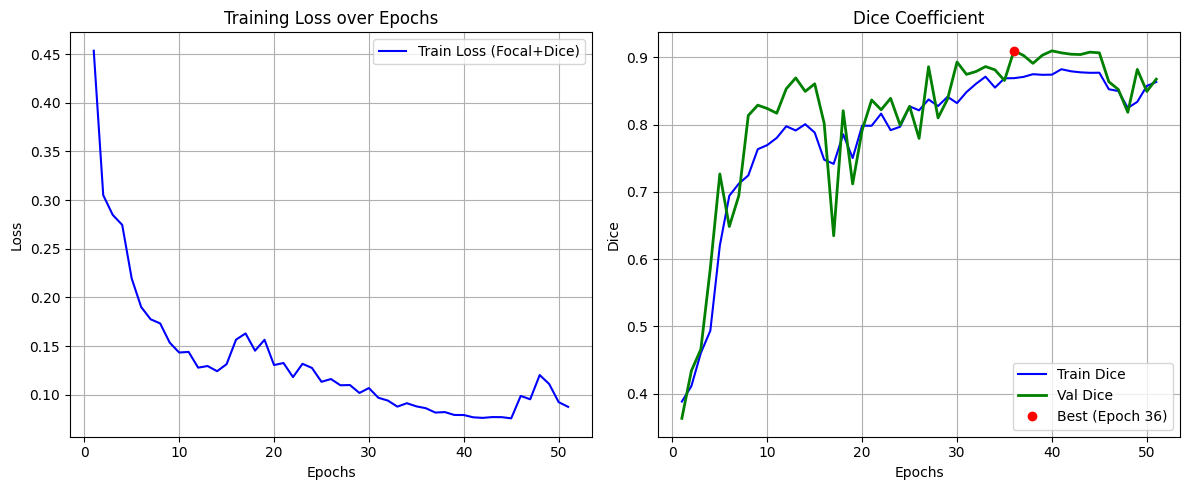


 PER-VIEW PERFORMANCE REPORT
View                 | Samples  | Mean Dice 
------------------------------------------
Anterior             | 9        | 0.9116
Left Lateral         | 8        | 0.9050
Right Lateral        | 12       | 0.8762
Left Oblique         | 10       | 0.9219
Right Oblique        | 10       | 0.9311


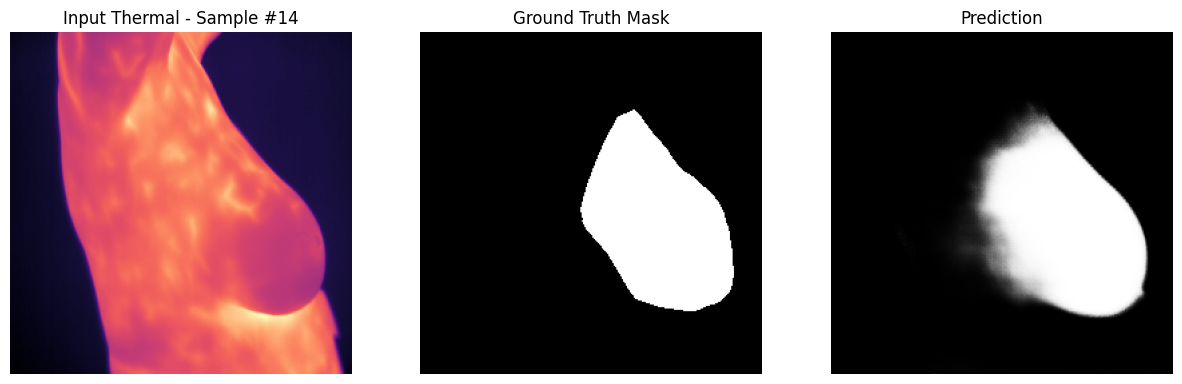

In [70]:
import matplotlib.pyplot as plt
import random

def plot_metrics(train_losses, val_dices, train_dices=None):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss (Focal+Dice)')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    if train_dices:
        plt.plot(epochs, train_dices, 'b-', label='Train Dice')
    plt.plot(epochs, val_dices, 'g-', label='Val Dice', linewidth=2)
    best_ep = val_dices.index(max(val_dices)) + 1
    plt.plot(best_ep, max(val_dices), 'ro', label=f'Best (Epoch {best_ep})')
    plt.title('Dice Coefficient')
    plt.xlabel('Epochs'); plt.ylabel('Dice')
    plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

try:
    plot_metrics(epoch_train_losses, epoch_val_dices, epoch_train_dices)
except NameError:
    print("Run training first to generate metrics.")

def evaluate_per_view(model, test_dataset, device):
    """Calculates Dice score for each of the 5 canonical views separately."""
    views = ["Anterior", "Left Lateral", "Right Lateral", "Left Oblique", "Right Oblique"]
    view_stats = {v: [] for v in views}
    
    model.eval()
    with torch.no_grad():
        for i in range(len(test_dataset)):
            img, mask = test_dataset[i]
            # Extract view name from the mask path in the base dataset
            # test_dataset is an AugmentedDataset -> wrapping a Subset -> wrapping a ThermalDataset
            subset = test_dataset.base
            orig_idx = subset.indices[i]
            full_path = subset.dataset.mask_paths[orig_idx]
            filename = os.path.basename(full_path)
            
            # Match view
            current_view = "Unknown"
            for v in views:
                if v.lower() in filename.lower():
                    current_view = v
                    break
            
            img_t = img.unsqueeze(0).to(device)
            mask_t = mask.unsqueeze(0).to(device)
            logits = model(img_t)
            dice = dice_coeff(logits, mask_t, from_logits=True).item()
            
            if current_view != "Unknown":
                view_stats[current_view].append(dice)

    print("\n" + "="*30)
    print(" PER-VIEW PERFORMANCE REPORT")
    print("="*30)
    print(f"{'View':<20} | {'Samples':<8} | {'Mean Dice':<10}")
    print("-" * 42)
    for v in views:
        scores = view_stats[v]
        if scores:
            mean_dice = sum(scores) / len(scores)
            print(f"{v:<20} | {len(scores):<8} | {mean_dice:.4f}")
        else:
            print(f"{v:<20} | 0        | N/A")
    print("="*30)

# ── Qualitative check ──
viz_ckpt = best_gpu_ckpt
if os.path.exists(viz_ckpt):
    model.load_state_dict(torch.load(viz_ckpt, weights_only=True))
    evaluate_per_view(model, test_set, device)
    
    # Random visual check
    model.eval()
    with torch.no_grad():
        sample_idx = random.randrange(len(test_set))
        img, mask = test_set[sample_idx]
        img_t = img.unsqueeze(0).to(device)
        logits = model(img_t)
        pred = torch.sigmoid(logits)

        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(img[0].cpu().squeeze(), cmap='magma')
        axs[0].set_title(f"Input Thermal - Sample #{sample_idx}")
        axs[1].imshow(mask.cpu().squeeze(), cmap='gray')
        axs[1].set_title("Ground Truth Mask")
        axs[2].imshow(pred.cpu().squeeze(), cmap='gray')
        axs[2].set_title("Prediction")
        for ax in axs: ax.axis('off')
        plt.show()

### Qualitative Checks

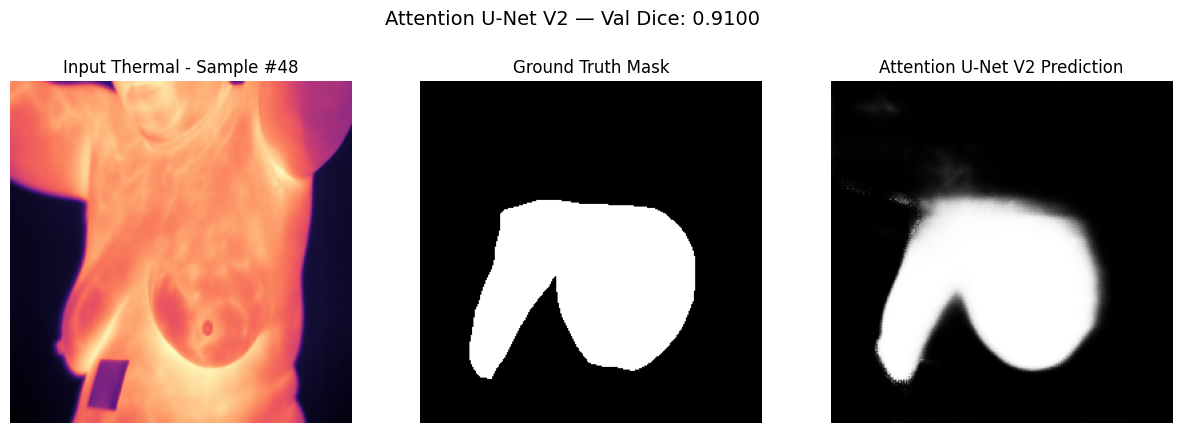

In [80]:
viz_ckpt = best_gpu_ckpt
if os.path.exists(viz_ckpt):
    model.load_state_dict(torch.load(viz_ckpt, weights_only=True))
    model.eval()
    with torch.no_grad():
        sample_idx = random.randrange(len(test_set))
        img, mask = test_set[sample_idx]
        img = img.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0)
        logits = model(img)
        pred = torch.sigmoid(logits)

        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(img[0, 0].cpu(), cmap='magma')
        axs[0].set_title(f"Input Thermal - Sample #{sample_idx}")
        axs[1].imshow(mask[0, 0].cpu(), cmap='gray')
        axs[1].set_title("Ground Truth Mask")
        axs[2].imshow(pred[0, 0].cpu(), cmap='gray')
        axs[2].set_title("Attention U-Net V2 Prediction")
        for ax in axs: ax.axis('off')
        plt.suptitle(f"Attention U-Net V2 — Val Dice: {best_gpu_dice:.4f}", fontsize=14)
        plt.show()

---

## Inference Pipeline - Automated Segmentation and Edge Extraction

This phase applies the trained U-Net to all TIFF files and saves a clean edge map for each image.

Per image, the pipeline does:

1. Min-max normalization
2. Forward pass through U-Net
3. Threshold at 0.5 to create a binary mask
4. Keep only the largest connected contour (noise suppression)
5. Run Canny edge detection on the cleaned mask
6. Save output as <original_name>_edge.png while preserving folder structure

The edge outputs become the direct input for anchor extraction in Phase 3.

In [81]:
output_edges = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/Automated_Edges4"

In [82]:
def automated_segmentation(model_path, tiff_dir, output_dir):
    model = AttentionUNet().to(device)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.eval()

    all_tiffs = glob.glob(os.path.join(tiff_dir, "**", "*.tiff"), recursive=True)
    os.makedirs(output_dir, exist_ok=True)

    print(f"Running automated segmentation on {len(all_tiffs)} images...")
    print(f"Model checkpoint: {model_path}")
    print(f"Output edge dir : {output_dir}")

    for f_path in tqdm(all_tiffs):
        raw = tiff.imread(f_path)
        t_min, t_max = np.min(raw), np.max(raw)
        norm = (raw - t_min) / (t_max - t_min + 1e-8)
        img_256 = cv2.resize(norm.astype(np.float32), (256, 256))

        img_tensor = torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_logits = model(img_tensor)
            pred = torch.sigmoid(pred_logits).squeeze().cpu().numpy()

        binary = (pred > 0.5).astype(np.uint8) * 255

        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        clean_mask = np.zeros_like(binary)
        if not contours:
            print(f"Warning: no contour found for {os.path.basename(f_path)}, skipping.")
            continue

        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(clean_mask, [largest], -1, 255, thickness=cv2.FILLED)

        edges = cv2.Canny(clean_mask, 100, 200)

        rel_path = os.path.relpath(f_path, tiff_dir)
        out_name = os.path.splitext(rel_path)[0] + "_edge.png"
        save_path = os.path.join(output_dir, out_name)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, edges)


model_weights = "breast_segmentation_attn_unet_v2_best.pth"
output_edges = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/Automated_Edges4"

if not os.path.exists(model_weights):
    raise FileNotFoundError(f"Model checkpoint not found: {model_weights}")

automated_segmentation(model_weights, TIFF_BASE, output_edges)

Running automated segmentation on 657 images...
Model checkpoint: breast_segmentation_attn_unet_v2_best.pth
Output edge dir : /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/Automated_Edges4


  0%|          | 0/657 [00:00<?, ?it/s]

---

### Edge-overlay quality check

This section randomly samples generated edge maps and overlays them in green on top of the original thermal image.

Why this is useful:

- Confirms that model boundaries align with anatomical breast contours.
- Quickly reveals failed masks, empty outputs, or corrupted files.
- Verifies that path handling remains stable on Windows/Unicode filenames.

The helper loader is intentionally robust against zero-byte and encoding-related read errors.

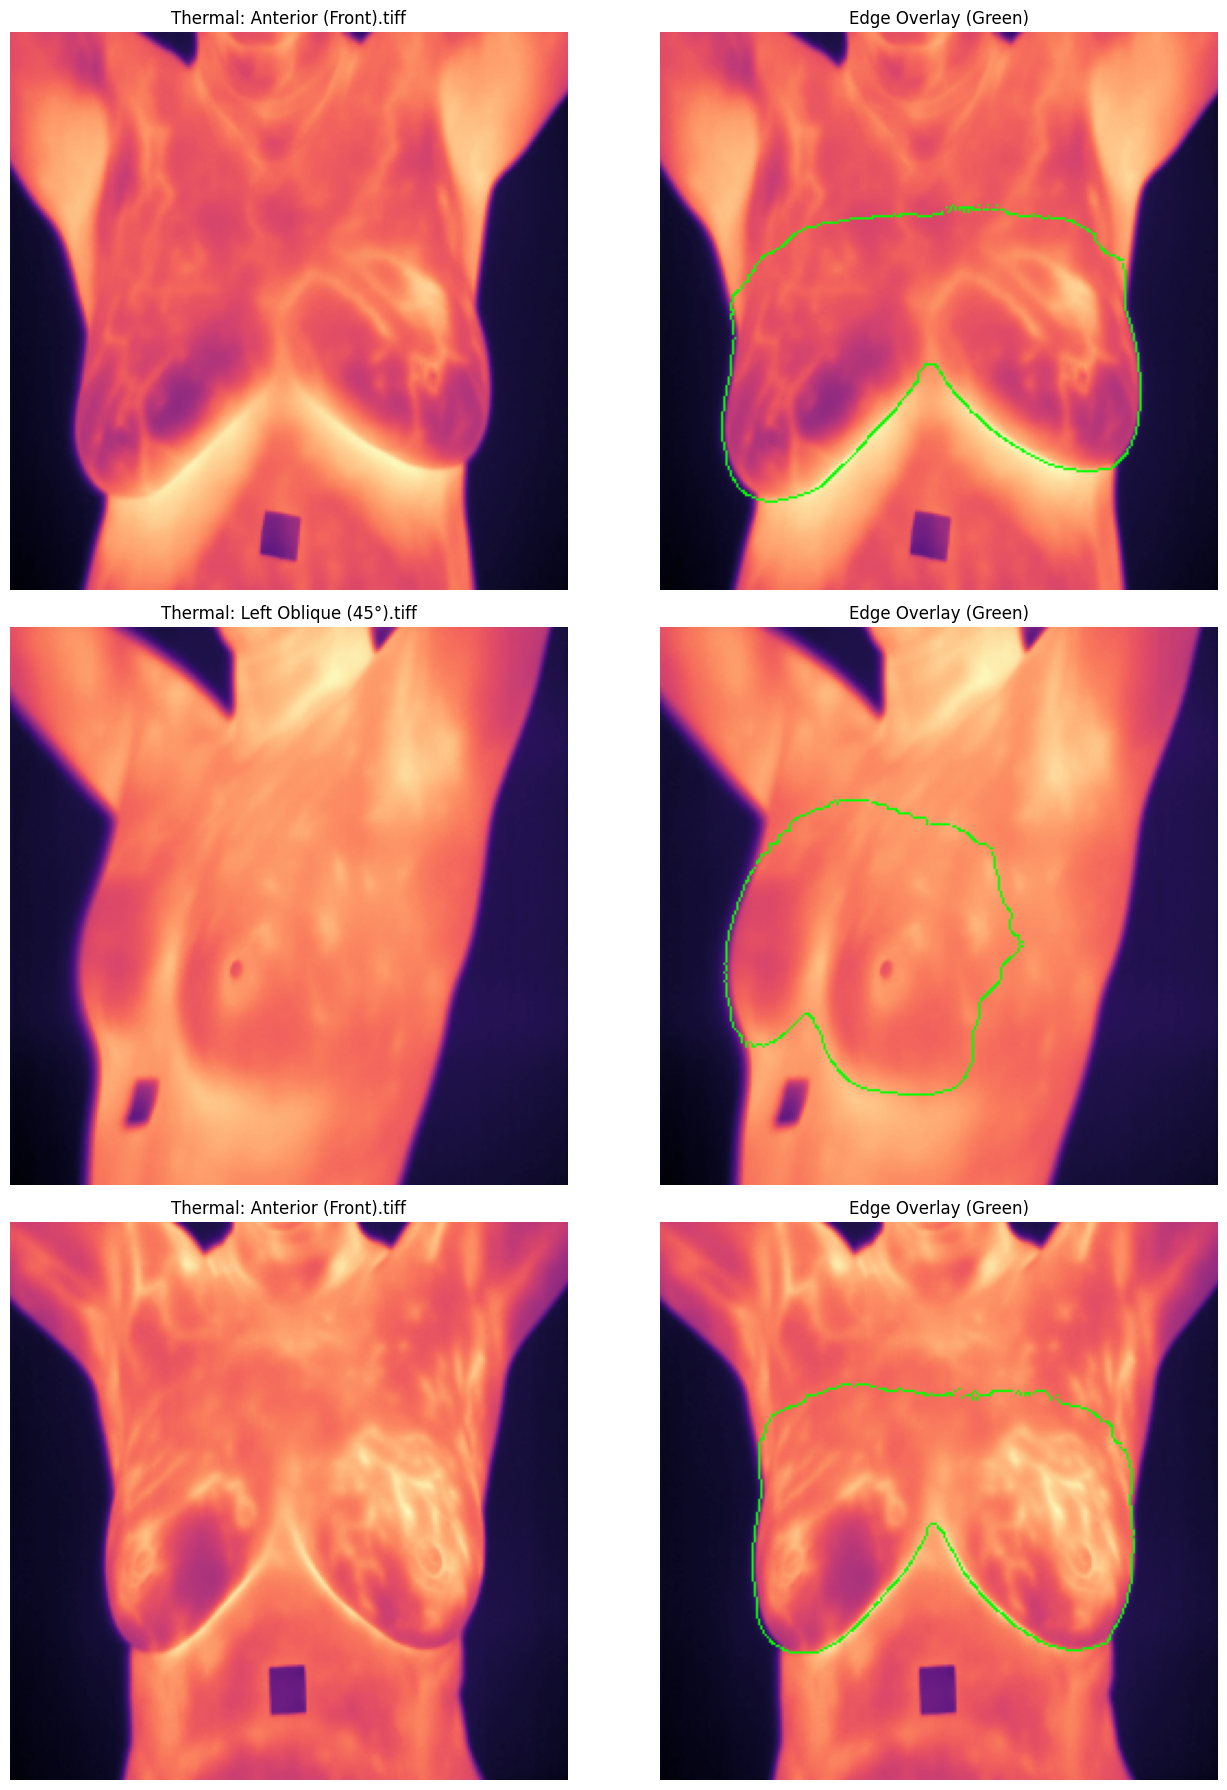

In [83]:
def robust_read_image(path, flags=cv2.IMREAD_GRAYSCALE):
    """Bypasses Windows path encoding issues and handles empty files."""
    try:
        if os.path.getsize(path) == 0:  # Check if file was stopped mid-save
            return None
        # Read file as a numpy array buffer to bypass string encoding
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, flags)
        return img
    except Exception:
        return None


def ultra_robust_light_test(tiff_dir, edge_dir, num_samples=3):
    # 1. Find all generated edge maps
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)

    if not edge_files:
        print("No edge files found! Check your Automated_Edges folder.")
        return

    # 2. Pick samples and setup plotting
    samples = random.sample(edge_files, min(num_samples, len(edge_files)))
    fig, axs = plt.subplots(len(samples), 2, figsize=(14, 6 * len(samples)))
    if len(samples) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, edge_path in enumerate(samples):
        # --- ROBUST READ ---
        edge_img = robust_read_image(edge_path)

        if edge_img is None:
            print(f"Skipping corrupted or unreadable edge map: {os.path.basename(edge_path)}")
            continue

        # 3. Find corresponding TIFF using Prefix Matching
        rel_path          = os.path.relpath(edge_path, edge_dir)
        patient_subfolder = os.path.dirname(rel_path)
        edge_filename     = os.path.basename(rel_path)
        search_folder     = os.path.join(tiff_dir, patient_subfolder)
        search_prefix     = edge_filename.split('(')[0].strip()

        potential_tiffs = glob.glob(os.path.join(search_folder, "*.tiff"))
        tiff_path = next((p for p in potential_tiffs if search_prefix in os.path.basename(p)), None)

        if tiff_path is None:
            continue

        # 4. Load/Normalize TIFF and Resize to 256x256
        raw      = tiff.imread(tiff_path)
        norm     = 255 * (raw - np.min(raw)) / (np.max(raw) - np.min(raw) + 1e-8)
        norm_256 = cv2.resize(norm.astype(np.uint8), (256, 256), interpolation=cv2.INTER_AREA)
        base_display = cv2.applyColorMap(norm_256, cv2.COLORMAP_MAGMA)

        # 5. Overlay edges
        overlay = base_display.copy()
        # The 'if edge_img is not None' check prevents the TypeError
        overlay[edge_img > 0] = [0, 255, 0]

        # Plotting
        axs[i, 0].imshow(cv2.cvtColor(base_display, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_title(f"Thermal: {os.path.basename(tiff_path)}")
        axs[i, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axs[i, 1].set_title("Edge Overlay (Green)")
        for ax in axs[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# Execute the test
ultra_robust_light_test(TIFF_BASE, output_edges, num_samples=3)
